In [78]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours
from tqdm.notebook import tqdm
import sys

plt.rcParams["figure.dpi"] = 150

In [23]:
def localized_state(size):
    psi0 = np.zeros(size, dtype = complex)
    beg = int(0.35*size)
    end = int(0.65*size)
    psi0[beg:end] = np.random.uniform(-1, 1, end-beg) + 1j * np.random.uniform(-1, 1, end-beg)
    psi0 /= np.linalg.norm(psi0)
    
    return psi0

def time_evol(U, n, psi0):

    for _ in range(1, n):
        psi = U@psi0
        psi0 = psi

    return psi

def system_size_dependence(sizes, kappa, alpha, beta):

    neg = np.zeros(len(sizes))
    for i, g in enumerate(tqdm(range(len(sizes)), desc="coupling")):
        U = diagonalize_floquet_operator(sizes[i], alpha, beta, kappa)
        psi0 = localized_state(sizes[i])
        psi = time_evol(U, 10, psi0)
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = np.sum(np.abs(W) - W)/2
        psi0 = psi

    return neg

In [27]:
def prime(end):
    prime_arr = []
    for i in range(1, end):
        c = 0
        for j in range(1, i):
            if i%j == 0:
                c += 1
        if c == 1:
            prime_arr.append(i)


    return prime_arr

sizes = prime(800)[1:]

In [33]:
def plot(sizes, kappa, params):
    n = len(params)
    ncols = 3                      # adjust if you want
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (alpha, beta) in zip(axes, params):
        neg = system_size_dependence(sizes, kappa, alpha, beta)
        ax.scatter(np.log(sizes), np.log(neg))
        ax.set_title(rf"$\alpha={alpha},\,\beta={beta}$")
        ax.set_xlabel(r"$\log(\mathrm{Size})$")
        ax.set_ylabel(r"$\log(\mathrm{Negativity})$")

    # turn off unused axes
    for ax in axes[len(params):]:
        ax.axis("off")

    fig.suptitle(rf"$\kappa = {kappa}$", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

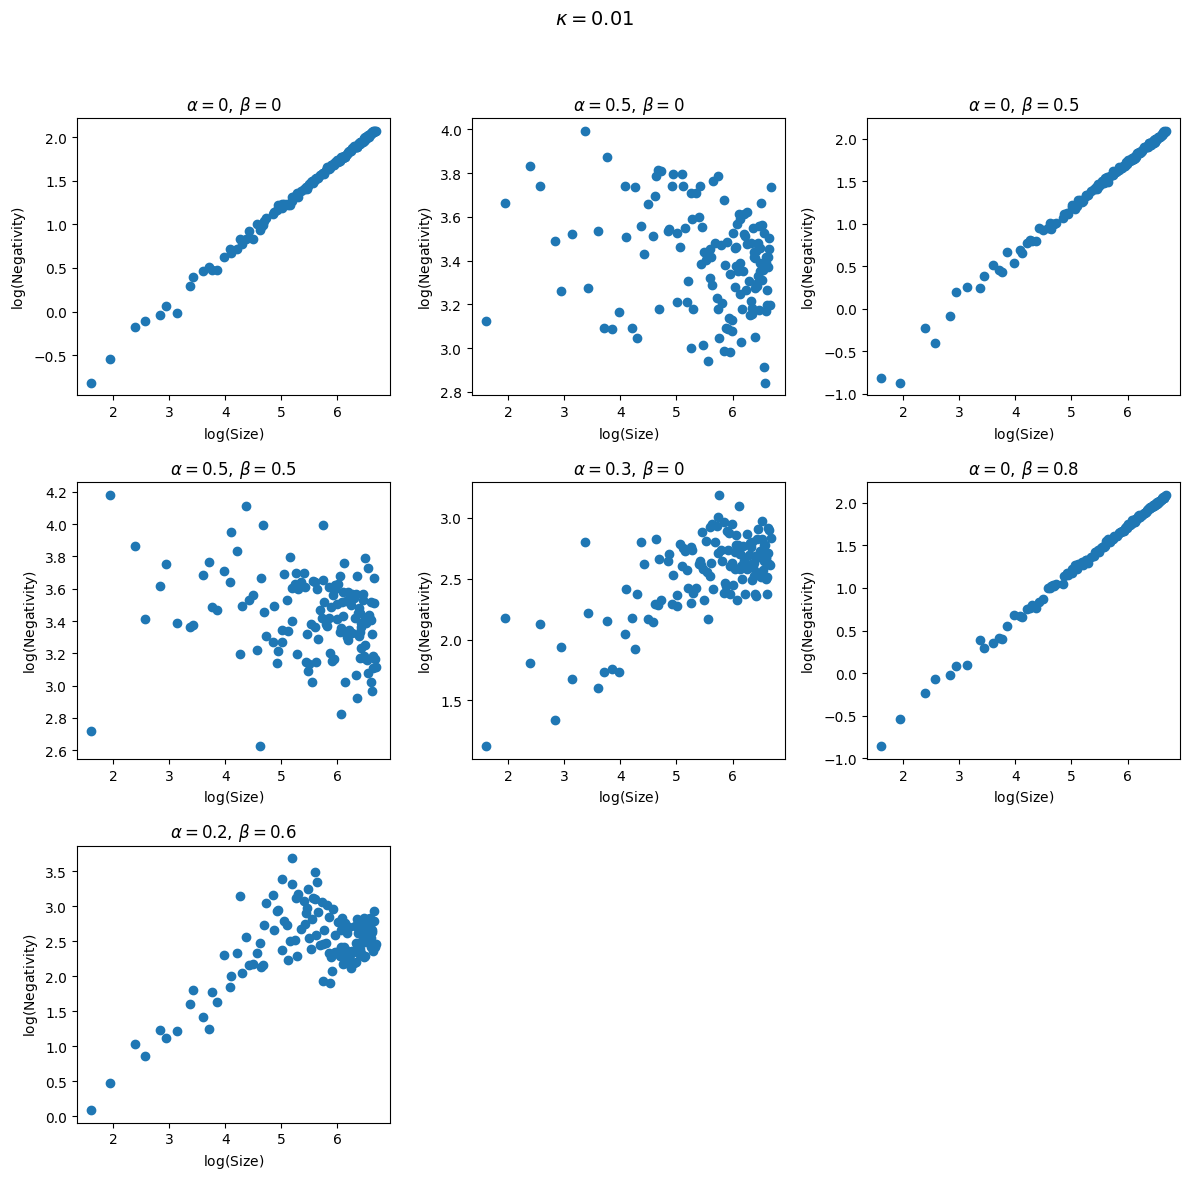

In [ ]:
params = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(sizes, 0.01, params)

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

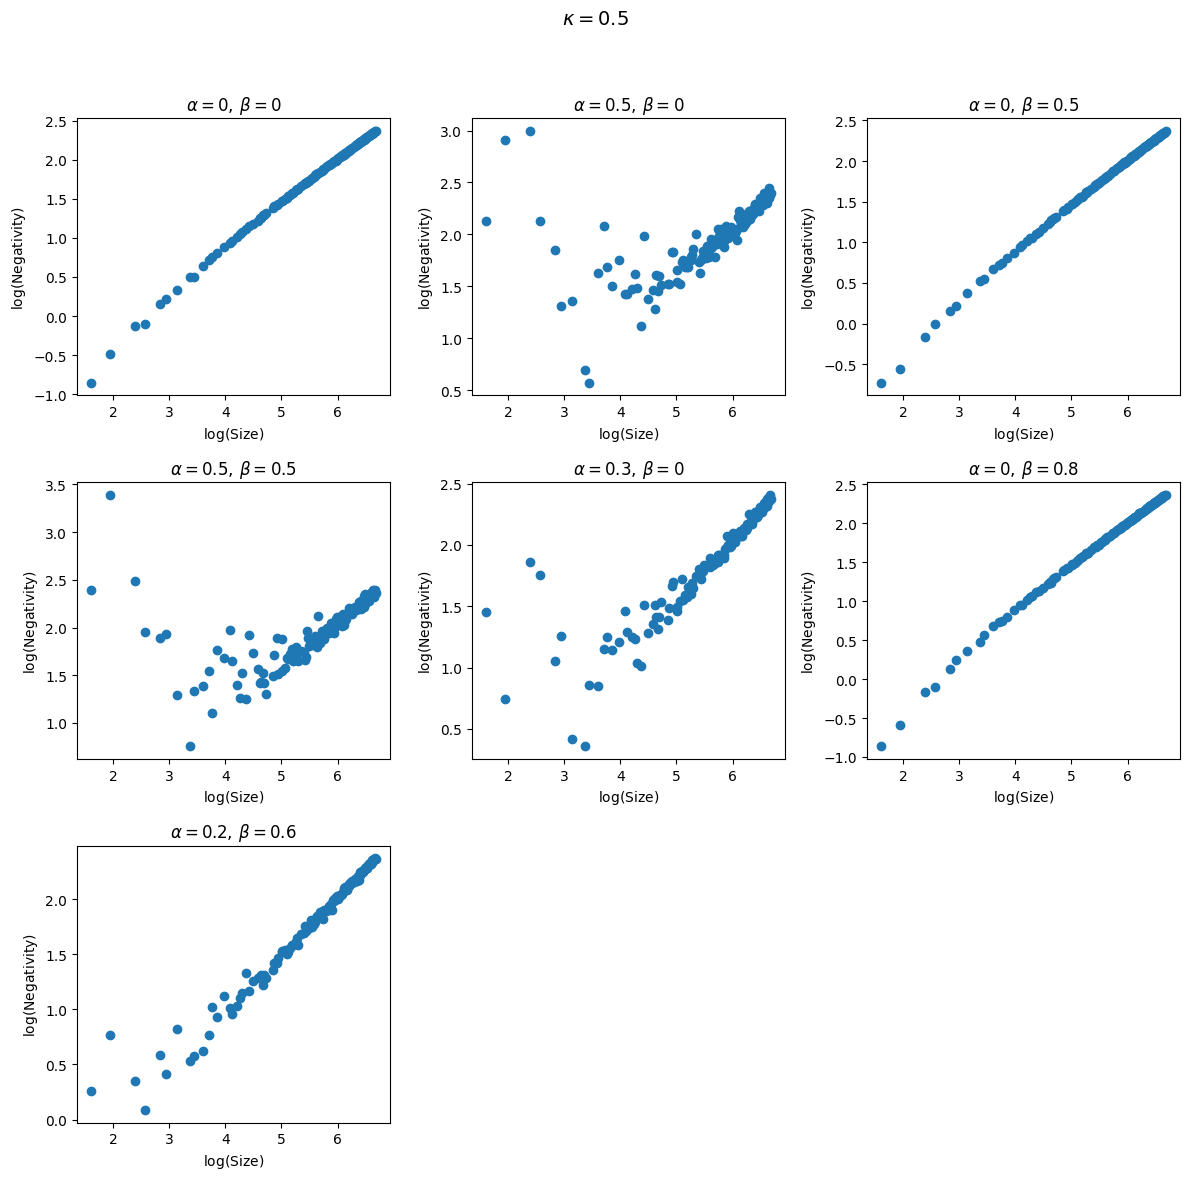

In [36]:
params2 = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(sizes, 0.5, params2)

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

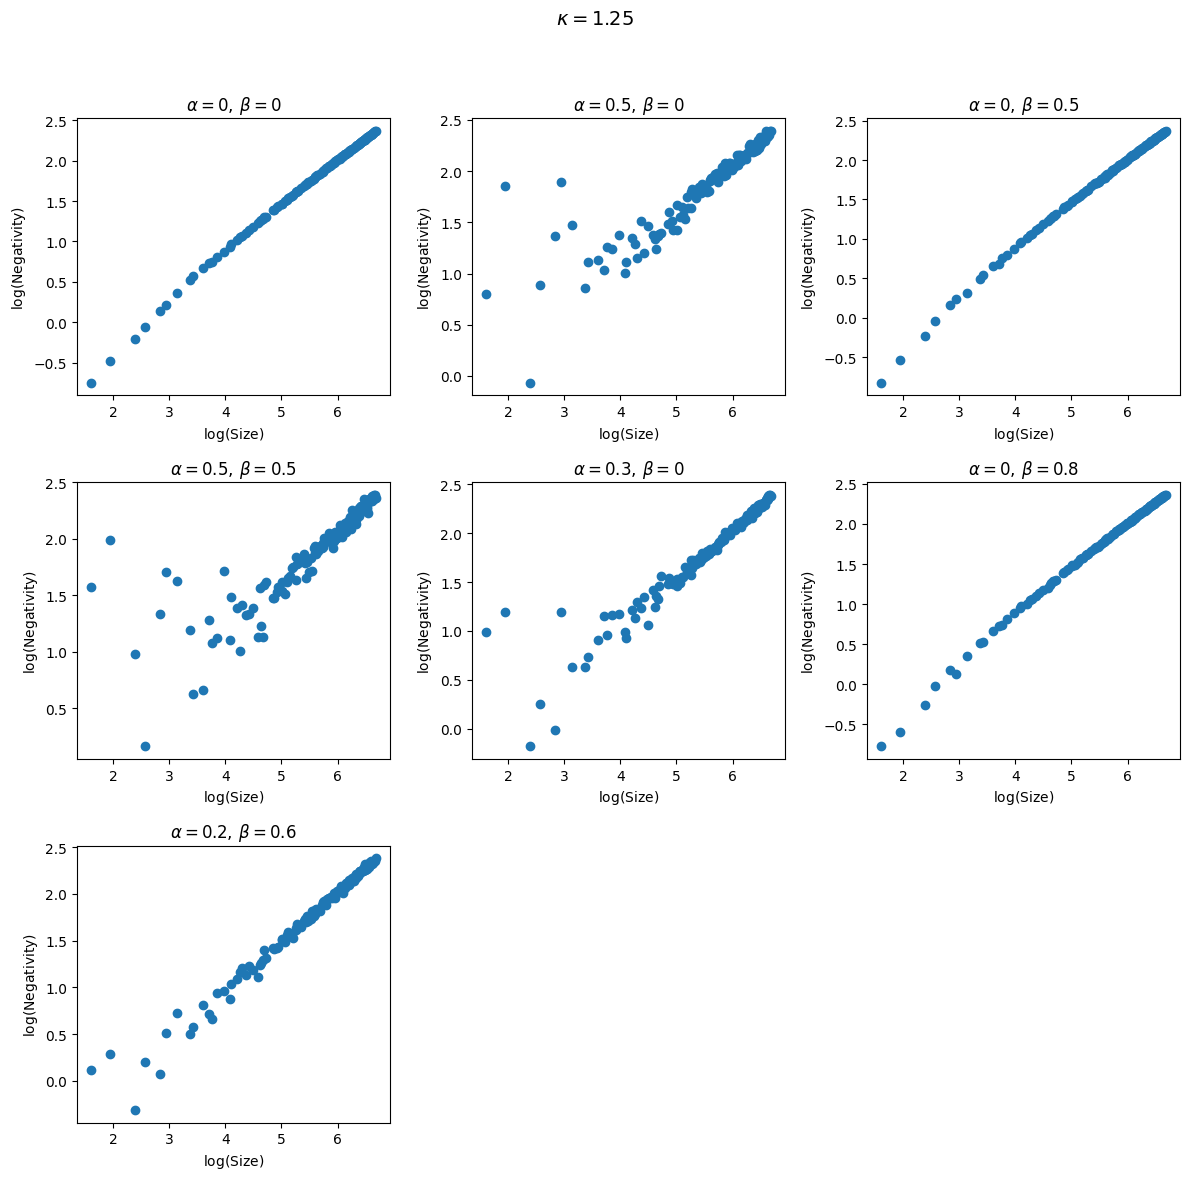

In [37]:
params3 = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(sizes, 1.25, params3)

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

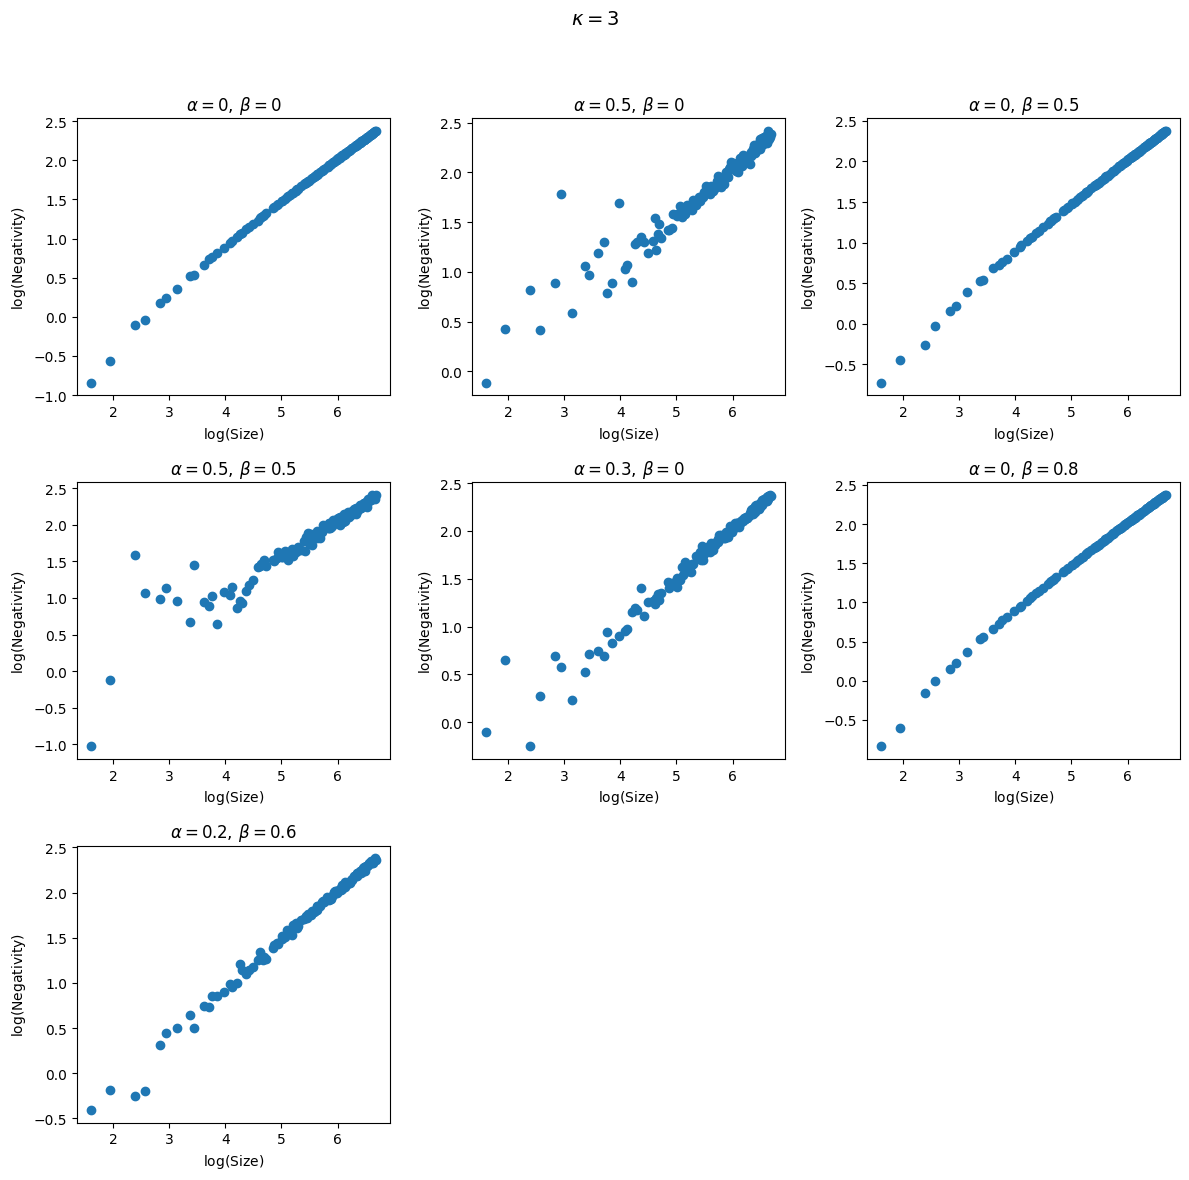

In [38]:
params2 = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(sizes, 3, params2)

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

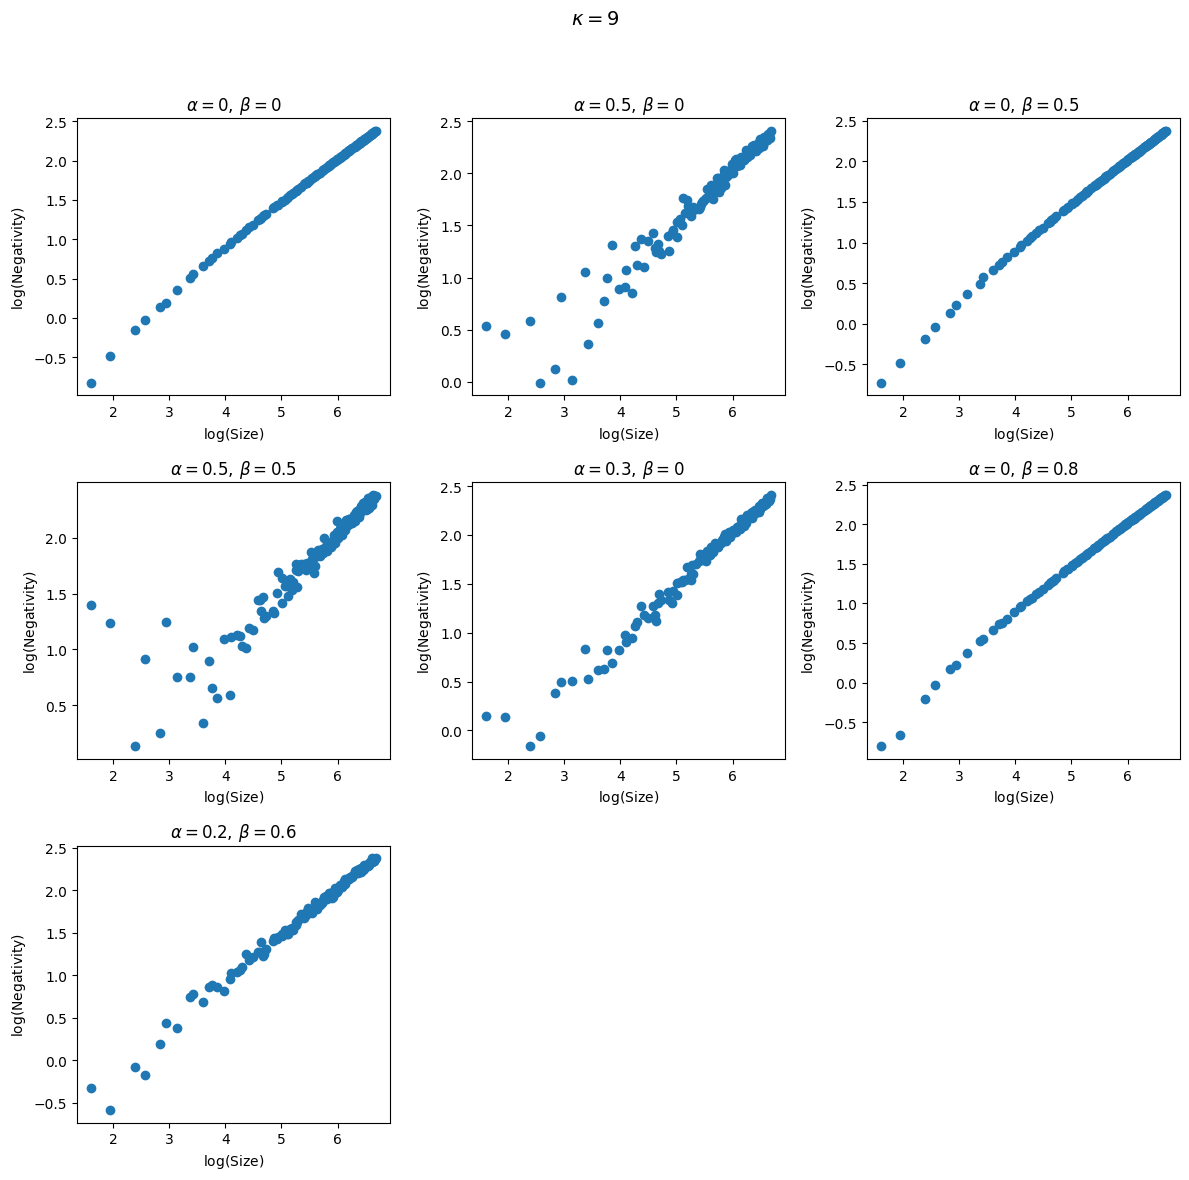

In [39]:
params2 = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(sizes, 9, params2)

Near integrable and maximally chaotic cases

Near integrable: $\kappa = 0.01$, $\alpha = 0$, $\beta = 0$. Breaking time reversal is changing the power law behaviour so.

Maximally chaotic: $\kappa = 10$, $\alpha \neq 0$, $\beta \neq 0$

In [79]:
alpha_int = 0; beta_int = 0
alpha_chaotic = 0.2; beta_chaotic = 0.6
kappa_int = 0.01
kappa_chaotic = 10
kappa_mixed1 = 1
kappa_mixed2 = 3

In [80]:
neg_int = system_size_dependence(sizes, kappa_int, beta_int, alpha_int)
neg_chaotic = system_size_dependence(sizes, kappa_chaotic, beta_chaotic, alpha_chaotic)
neg_mixed1 = system_size_dependence(sizes, kappa_mixed1, beta_chaotic, alpha_chaotic)
neg_mixed2 = system_size_dependence(sizes, kappa_mixed2, beta_chaotic, alpha_chaotic)

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

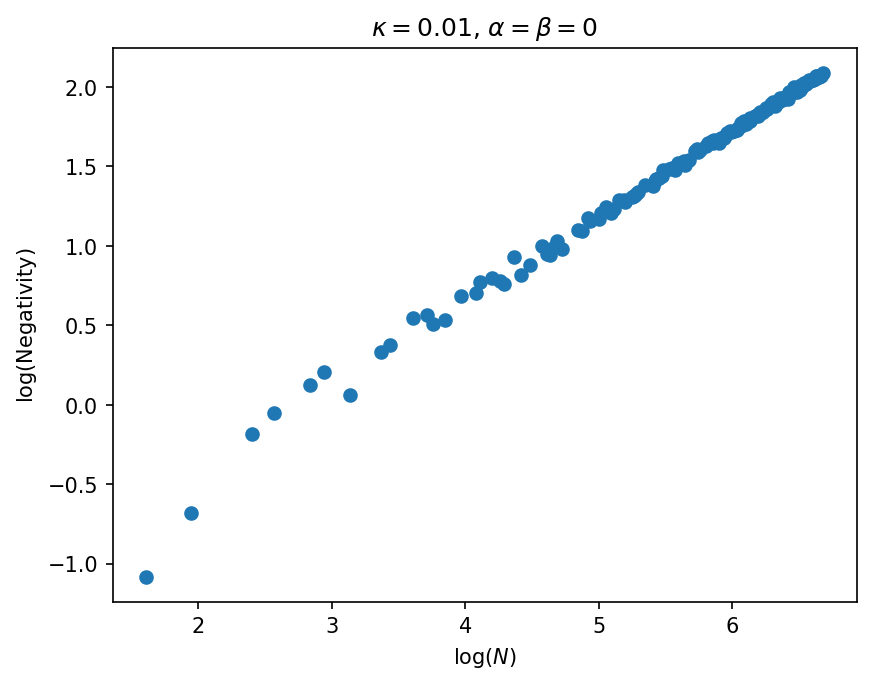

In [81]:
plt.scatter(np.log(sizes), np.log(neg_int))
plt.xlabel(rf"$\log(N)$")
plt.ylabel(r"$\log(\text{Negativity})$")
plt.title(rf"$\kappa = {kappa_int}$, $\alpha = \beta = {alpha_int}$")
plt.show()

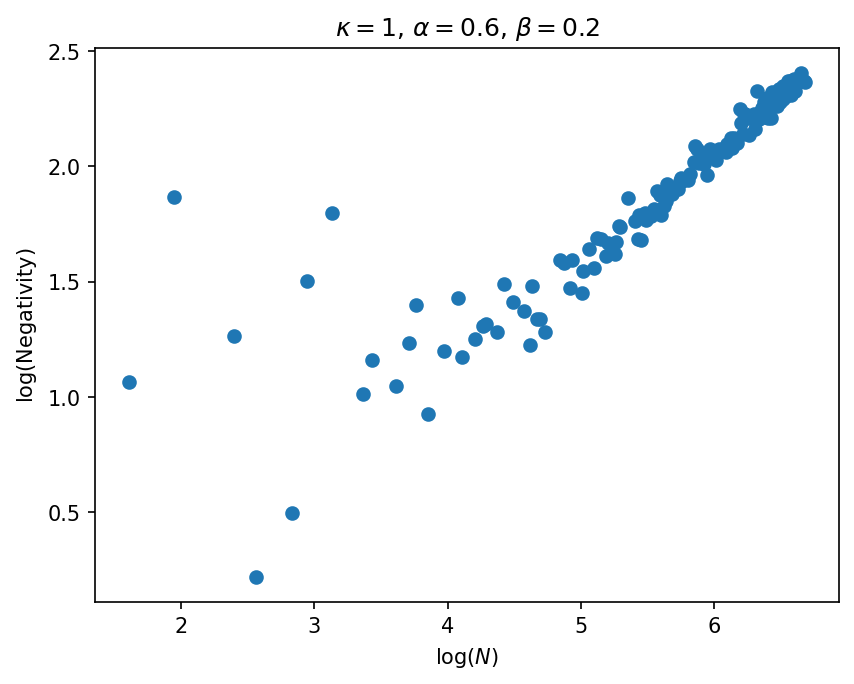

In [82]:
plt.scatter(np.log(sizes), np.log(neg_mixed1))
plt.xlabel(rf"$\log(N)$")
plt.ylabel(r"$\log(\text{Negativity})$")
plt.title(rf"$\kappa = {kappa_mixed1}$, $\alpha = {beta_chaotic}$, $\beta = {alpha_chaotic}$")
plt.show()

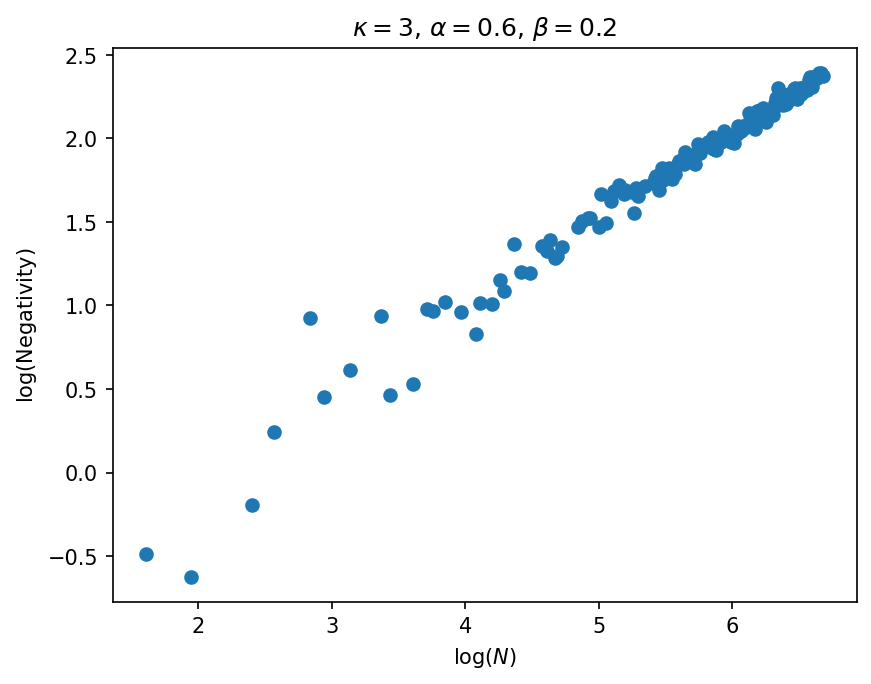

In [83]:
plt.scatter(np.log(sizes), np.log(neg_mixed2))
plt.xlabel(rf"$\log(N)$")
plt.ylabel(r"$\log(\text{Negativity})$")
plt.title(rf"$\kappa = {kappa_mixed2}$, $\alpha = {beta_chaotic}$, $\beta = {alpha_chaotic}$")
plt.show()

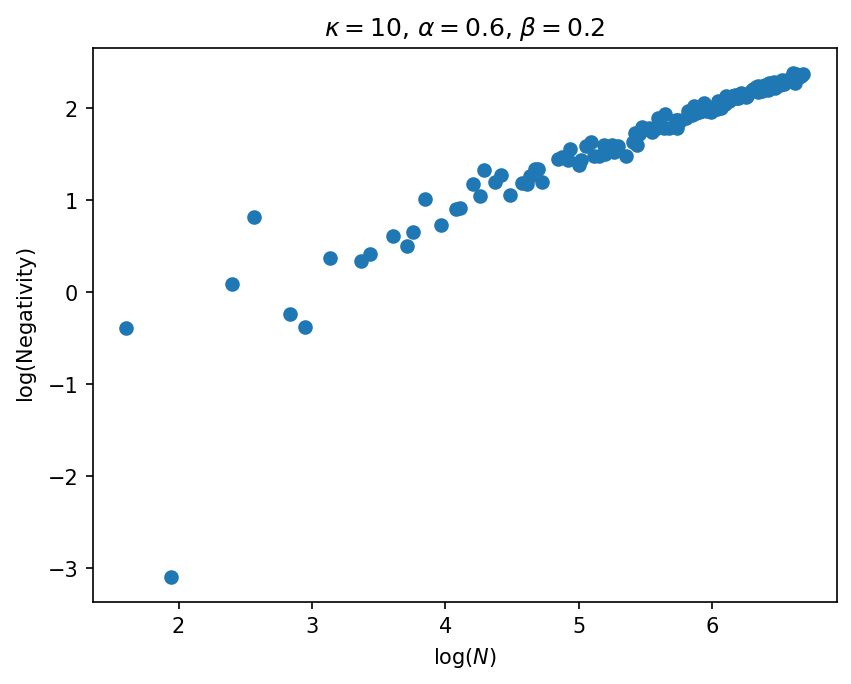

In [84]:
plt.scatter(np.log(sizes), np.log(neg_chaotic))
plt.xlabel(rf"$\log(N)$")
plt.ylabel(r"$\log(\text{Negativity})$")
plt.title(rf"$\kappa = {kappa_chaotic}$, $\alpha = {beta_chaotic}$, $\beta = {alpha_chaotic}$")
plt.show()

In [85]:
neg_another = system_size_dependence(sizes, 10, 0.3, 0)
neg_another1 = system_size_dependence(sizes, 10, 0, 0.3)

coupling:   0%|          | 0/138 [00:00<?, ?it/s]

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_61479/4250445521.py:6: RuntimeWarning: invalid value encountered in divide
  psi0 /= np.linalg.norm(psi0)


coupling:   0%|          | 0/138 [00:00<?, ?it/s]

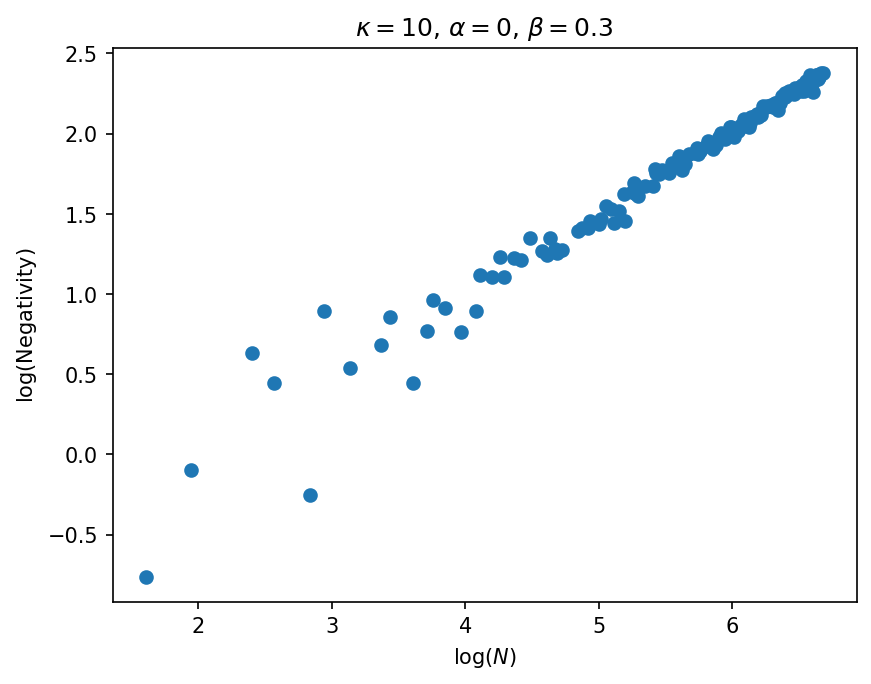

In [88]:
plt.scatter(np.log(sizes), np.log(neg_another))
plt.xlabel(rf"$\log(N)$")
plt.ylabel(r"$\log(\text{Negativity})$")
plt.title(rf"$\kappa = {kappa_chaotic}$, $\alpha = {0}$, $\beta = {0.3}$")
plt.show()

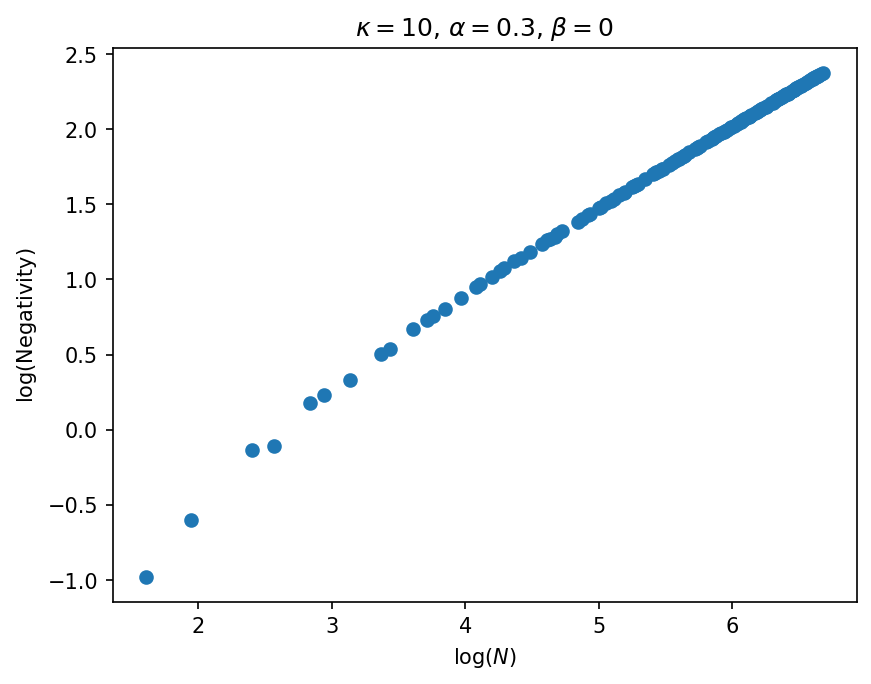

In [89]:
plt.scatter(np.log(sizes), np.log(neg_another1))
plt.xlabel(rf"$\log(N)$")
plt.ylabel(r"$\log(\text{Negativity})$")
plt.title(rf"$\kappa = {kappa_chaotic}$, $\alpha = {0.3}$, $\beta = {0}$")
plt.show()